In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [7]:
df= pd.DataFrame()

In [8]:
df["x1"]= [1,2,3,4,5,6,6,7,8,9]
df["x2"]= [3,5,2,6,9,6,2,4,8,6]
df["label"]= [1,1,0,1,0,1,0,0,1,1]

In [9]:
df

,x1,x2,label
0,1,3,1
1,2,5,1
2,3,2,0
3,4,6,1
4,5,9,0
5,6,6,1
6,6,2,0
7,7,4,0
8,8,8,1
9,9,6,1


<Axes: xlabel='x1', ylabel='x2'>

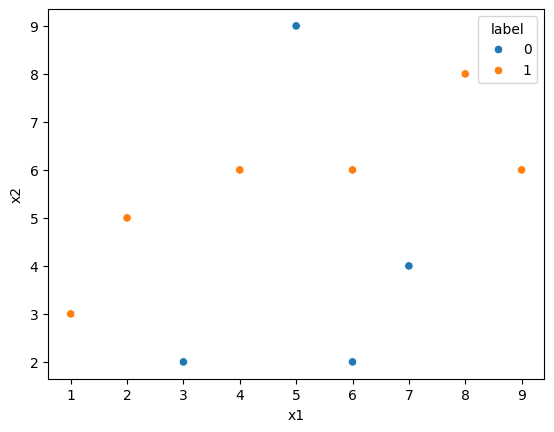

In [10]:
sns.scatterplot(data=df, x="x1",y="x2",hue="label")

In [11]:
df["weight"]=1/df.shape[0]

In [12]:
df

,x1,x2,label,weight
0,1,3,1,0.1
1,2,5,1,0.1
2,3,2,0,0.1
3,4,6,1,0.1
4,5,9,0,0.1
5,6,6,1,0.1
6,6,2,0,0.1
7,7,4,0,0.1
8,8,8,1,0.1
9,9,6,1,0.1


In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
dtc=DecisionTreeClassifier(max_depth=1)

In [17]:
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [19]:
dtc.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.625, 0.5, '  False')]

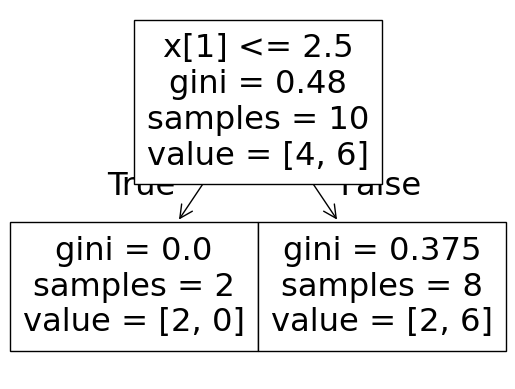

In [22]:
plot_tree(dtc)

<Axes: >

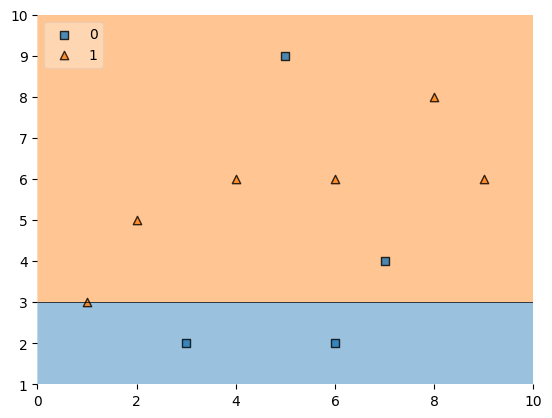

In [23]:
plot_decision_regions(x,y,clf=dtc,legend=2)

In [24]:
df["y_pred"]=dtc.predict(x)

In [25]:
df

,x1,x2,label,weight,y_pred
0,1,3,1,0.1,1
1,2,5,1,0.1,1
2,3,2,0,0.1,0
3,4,6,1,0.1,1
4,5,9,0,0.1,1
5,6,6,1,0.1,1
6,6,2,0,0.1,0
7,7,4,0,0.1,1
8,8,8,1,0.1,1
9,9,6,1,0.1,1


In [26]:
def calculate_model_weight(error):
    return 0.5*(np.log((1-error)/(error)))

In [28]:
aplha1=calculate_model_weight(0.2)
aplha1

np.float64(0.6931471805599453)

In [29]:
def upgrade_row_weight(row,aplha=0.693):
   if row["label"] == row["y_pred"]:
       return row["weight"] *np.exp(-aplha)
   else:
       return row["weight"] *np.exp(aplha)


In [30]:
df["upd_weight"]= df.apply(upgrade_row_weight,axis=1)

In [31]:
df

,x1,x2,label,weight,y_pred,upd_weight
0,1,3,1,0.1,1,0.050007
1,2,5,1,0.1,1,0.050007
2,3,2,0,0.1,0,0.050007
3,4,6,1,0.1,1,0.050007
4,5,9,0,0.1,1,0.199971
5,6,6,1,0.1,1,0.050007
6,6,2,0,0.1,0,0.050007
7,7,4,0,0.1,1,0.199971
8,8,8,1,0.1,1,0.050007
9,9,6,1,0.1,1,0.050007


In [32]:
df["normalised_weight"]=df["upd_weight"]/df["upd_weight"].sum()

In [33]:
df

,x1,x2,label,weight,y_pred,upd_weight,normalised_weight
0,1,3,1,0.1,1,0.050007,0.062509
1,2,5,1,0.1,1,0.050007,0.062509
2,3,2,0,0.1,0,0.050007,0.062509
3,4,6,1,0.1,1,0.050007,0.062509
4,5,9,0,0.1,1,0.199971,0.249963
5,6,6,1,0.1,1,0.050007,0.062509
6,6,2,0,0.1,0,0.050007,0.062509
7,7,4,0,0.1,1,0.199971,0.249963
8,8,8,1,0.1,1,0.050007,0.062509
9,9,6,1,0.1,1,0.050007,0.062509


In [34]:
df["cumsum_upper"]=np.cumsum(df["normalised_weight"])
df["cumsum_lower"]= df["cumsum_upper"]-df["normalised_weight"]

In [35]:
df

,x1,x2,label,weight,y_pred,upd_weight,normalised_weight,cumsum_upper,cumsum_lower
0,1,3,1,0.1,1,0.050007,0.062509,0.062509,0.000000
1,2,5,1,0.1,1,0.050007,0.062509,0.125018,0.062509
2,3,2,0,0.1,0,0.050007,0.062509,0.187528,0.125018
3,4,6,1,0.1,1,0.050007,0.062509,0.250037,0.187528
4,5,9,0,0.1,1,0.199971,0.249963,0.500000,0.250037
5,6,6,1,0.1,1,0.050007,0.062509,0.562509,0.500000
6,6,2,0,0.1,0,0.050007,0.062509,0.625018,0.562509
7,7,4,0,0.1,1,0.199971,0.249963,0.874982,0.625018
8,8,8,1,0.1,1,0.050007,0.062509,0.937491,0.874982
9,9,6,1,0.1,1,0.050007,0.062509,1.000000,0.937491


In [36]:
def gen_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row["cumsum_lower"]<a and row["cumsum_upper"]>a:
                indices.append(index)
    return indices

In [39]:
index_value = gen_new_dataset(df)
index_value

[4, 7, 3, 7, 7, 2, 0, 1, 5, 8]

In [40]:
second_df=df.iloc[index_value,0:4]
second_df

,x1,x2,label,weight
4,5,9,0,0.1
7,7,4,0,0.1
3,4,6,1,0.1
7,7,4,0,0.1
7,7,4,0,0.1
2,3,2,0,0.1
0,1,3,1,0.1
1,2,5,1,0.1
5,6,6,1,0.1
8,8,8,1,0.1


In [48]:
dt2=DecisionTreeClassifier(max_depth=1)

In [49]:
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values


In [50]:
dt2.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 4.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

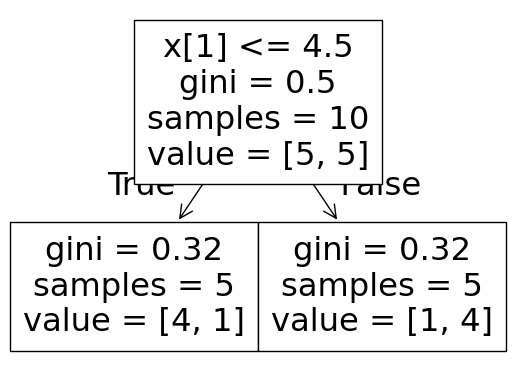

In [51]:
plot_tree(dt2)

<Axes: >

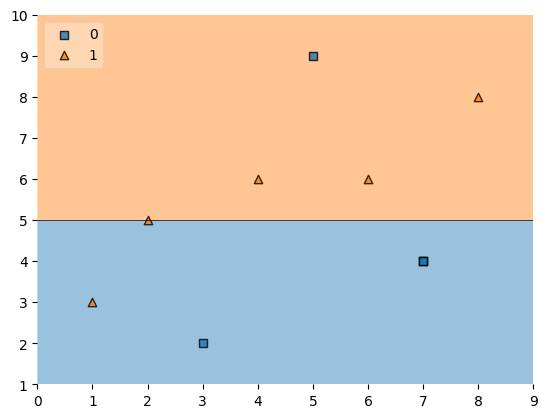

In [52]:
plot_decision_regions(x,y,clf=dt2,legend=2)

In [53]:
second_df["y_pred"]=dt2.predict(x)

In [54]:
second_df

,x1,x2,label,weight,y_pred
4,5,9,0,0.1,1
7,7,4,0,0.1,0
3,4,6,1,0.1,1
7,7,4,0,0.1,0
7,7,4,0,0.1,0
2,3,2,0,0.1,0
0,1,3,1,0.1,0
1,2,5,1,0.1,1
5,6,6,1,0.1,1
8,8,8,1,0.1,1
